In [1]:
# Import dependencies
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA

import prepSpec as preps

## Basics of spectra (pre)processing

In [2]:
### load data
data = pd.read_csv('spec_all.csv', header=None, skiprows=1)
data

,0,1,2,3,4,5,6,7,8,9,...,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375
0,400.000000,402.000000,404.000000,406.0,408.000000,410.0,412.000000,414.0,416.000000,418.0,...,3132.0,3134.000000,3136.000000,3138.000000,3140.0,3142.0,3144.000000,3146.000000,3148.0,3150.0
1,2087.880477,2081.301202,2064.093031,2044.0,2027.077310,2016.0,2011.765015,2012.0,2014.487631,2021.0,...,1121.0,1119.662203,1116.971070,1108.757012,1096.5,1086.5,1093.715257,1106.290406,1109.0,1099.0
2,1996.888902,1989.193856,1968.247405,1947.5,1944.414062,1955.0,1969.569068,1977.5,1971.622167,1959.5,...,1074.5,1077.075575,1078.206787,1068.894946,1068.0,1076.0,1080.542195,1080.391302,1070.0,1049.0
3,1713.384893,1716.148881,1702.320701,1684.0,1682.955905,1683.0,1666.769022,1651.0,1652.468009,1654.0,...,988.5,991.534139,1001.211144,1001.859529,993.0,983.0,985.596481,994.449681,997.0,989.5
4,2234.751288,2240.015819,2225.396236,2205.5,2215.801656,2236.0,2237.332850,2214.5,2173.179446,2139.5,...,1122.0,1136.481504,1128.296034,1110.460110,1112.5,1112.0,1128.744868,1135.244226,1124.5,1119.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2706,2054.247185,2054.776490,2038.780923,2019.0,2024.473587,2032.0,2016.947969,2002.5,2013.422037,2033.0,...,1248.0,1254.847988,1264.911639,1259.306223,1256.5,1258.5,1249.111850,1251.163158,1265.0,1264.0
2707,1275.984900,1282.244094,1289.081091,1288.5,1275.143820,1261.5,1259.134153,1258.0,1248.257069,1242.5,...,1079.0,1081.753860,1078.747664,1064.850154,1060.0,1080.5,1090.532787,1076.754284,1063.0,1081.5
2708,1645.972490,1638.364289,1631.889306,1631.0,1635.458649,1643.0,1649.532118,1645.5,1626.787880,1616.5,...,1209.5,1197.067766,1197.384240,1205.942618,1202.5,1194.5,1177.950564,1180.190198,1194.5,1190.5
2709,1824.456890,1826.232457,1825.134223,1814.5,1799.828845,1791.5,1797.081840,1808.5,1816.093796,1819.5,...,1182.0,1190.688659,1198.033704,1196.313233,1205.5,1211.0,1198.553647,1189.602691,1193.0,1196.5


In [3]:
### load labels
meta = pd.read_csv('meta_all.csv', header=0)
meta

,labels,batches
0,E.coli,1
1,E.coli,1
2,E.coli,1
3,E.coli,1
4,E.coli,1
...,...,...
2705,S.warneri,9
2706,S.warneri,9
2707,S.warneri,9
2708,S.warneri,9


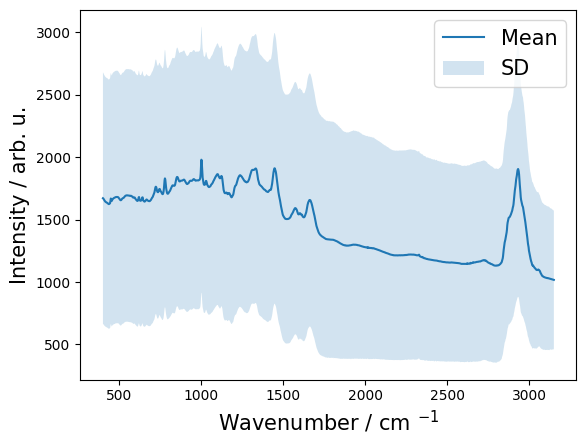

In [4]:
### plot data
wn = np.array(data.iloc[0, :])
spec = np.array(data.iloc[1:, :])
labels = np.array(meta['labels'])
batches = np.array(meta['batches'])

spec_mean = spec.mean(axis=0)
spec_sd = spec.std(axis=0)

plt.plot(wn, spec_mean, label='Mean')
plt.fill_between(wn, spec_mean - spec_sd, 
                 spec_mean + spec_sd, 
                 alpha = 0.2, label='SD')
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.legend(fontsize=15)

### Baseline correction

In Raman spectra, Raman signal is usually accompanied by fluoresence, which is manifested as slowly changing profile underneath the Raman bands

Baseline correction is a mathematical approach to remove the fluorecence and retain 'pure' Raman signal.

It is more commonly applied than 'hardware'-based approaches due to the low cost.

Basic idea of baseline correction:
* estimate baseline via certain functions, such as polynomial.
* subtract estimated baseline


SNIP: Statistics-sensitive Non-linear Iterative Peak-clipping
    
* replaces each value with the minimum of itself and the average of its left and right neighbors

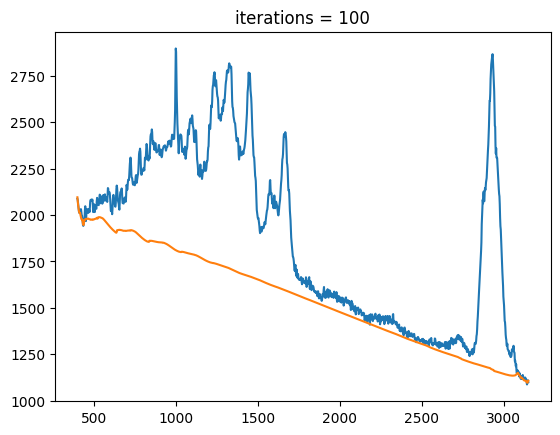

In [5]:
### estimate baseline
bs = preps.snip(spec, iterations=100, smoothing_window=9, lls=True, return_baseline=True)

plt.plot(wn, spec[0, :], label='example spectrum')
plt.plot(wn, bs[0, :], label='estimated baseline')
plt.title('iterations = 100')
plt.show()

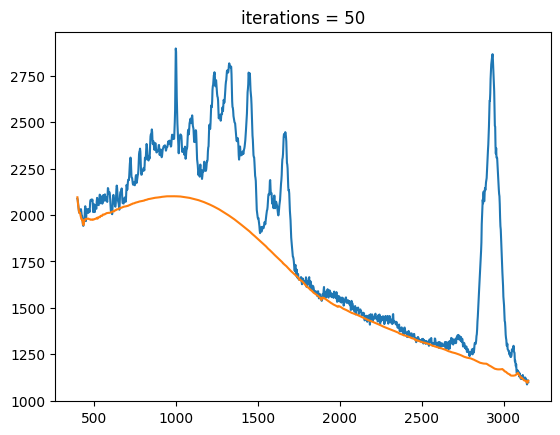

In [6]:
### estimate baseline
bs = preps.snip(spec, iterations=50, smoothing_window=9, lls=True, return_baseline=True)

plt.plot(wn, spec[0, :], label='example spectrum')
plt.plot(wn, bs[0, :], label='estimated baseline')
plt.title('iterations = 50')
plt.show()

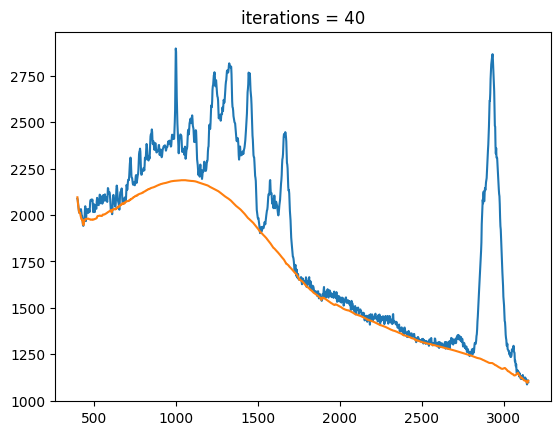

In [7]:
### estimate baseline
bs = preps.snip(spec, iterations=40, smoothing_window=9, lls=True, return_baseline=True)

plt.plot(wn, spec[0, :], label='example spectrum')
plt.plot(wn, bs[0, :], label='estimated baseline')
plt.title('iterations = 40')
plt.show()

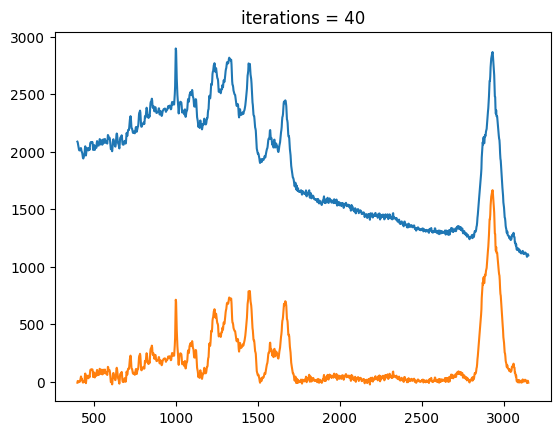

In [8]:
### remove baseline:
spec_bc = spec - bs
plt.plot(wn, spec[0, :], label='example spectrum')
plt.plot(wn, spec_bc[0, :], label='corrected spectrum')
plt.title('iterations = 40')
plt.show()

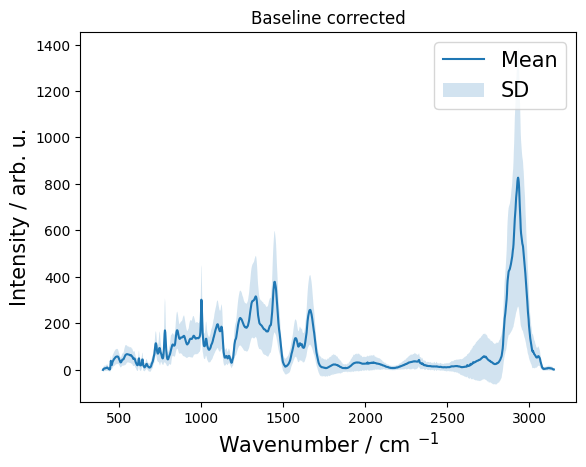

In [9]:
### one-step version

### estimate baseline
spec = preps.snip(spec, iterations=40, smoothing_window=9, lls=True, return_baseline=False)

spec_mean = spec.mean(axis=0)
spec_sd = spec.std(axis=0)

plt.plot(wn, spec_mean, label='Mean')
plt.fill_between(wn, spec_mean - spec_sd, 
                 spec_mean + spec_sd, 
                 alpha = 0.2, label='SD')
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.legend(fontsize=15)
plt.title('Baseline corrected')
plt.show()

### Normalization
Important to:
* reduce the possible intensity fluctuations coming from e.g. laser power, focusing status, etc.
* obain a more stable model, expecially deep learning models, as they work optimally with values within 0-1

Different ways of normalization:
* divide by square root of sum of squares (l2 normalization)
* divide by maximum
* divide by median/mean
* divide by range (maximum-minimum)

All above options can be done based on the full spectral range, part of the spectral range, or a single band.             

In [10]:
### here we will do l2 normalization excluding the silent region
ix_wn = (wn<1800) | (wn>2800)
wn = wn[ix_wn]
spec = spec[:, ix_wn]

spec = np.row_stack([spec[i, :]/np.sqrt(np.sum(spec[i, :]**2)) for i in range(spec.shape[0])])

Text(0.5, 1.0, 'After l2 normalization')

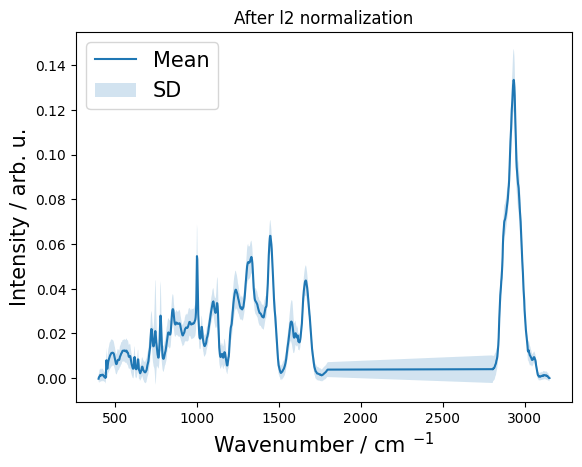

In [11]:
spec_mean = spec.mean(axis=0)
spec_sd = spec.std(axis=0)

plt.plot(wn, spec_mean, label='Mean')
plt.fill_between(wn, spec_mean - spec_sd, 
                 spec_mean + spec_sd, 
                 alpha = 0.2, label='SD')
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.legend(fontsize=15)
plt.title('After l2 normalization')

### Feature extraction / dimension reduction

Important to reduce the redundancy in the data, which often leads to better performance for subsequent analysis (e.g., clustering, classification, etc.)

#### Principal component analysis: unsupervised dimension reduction

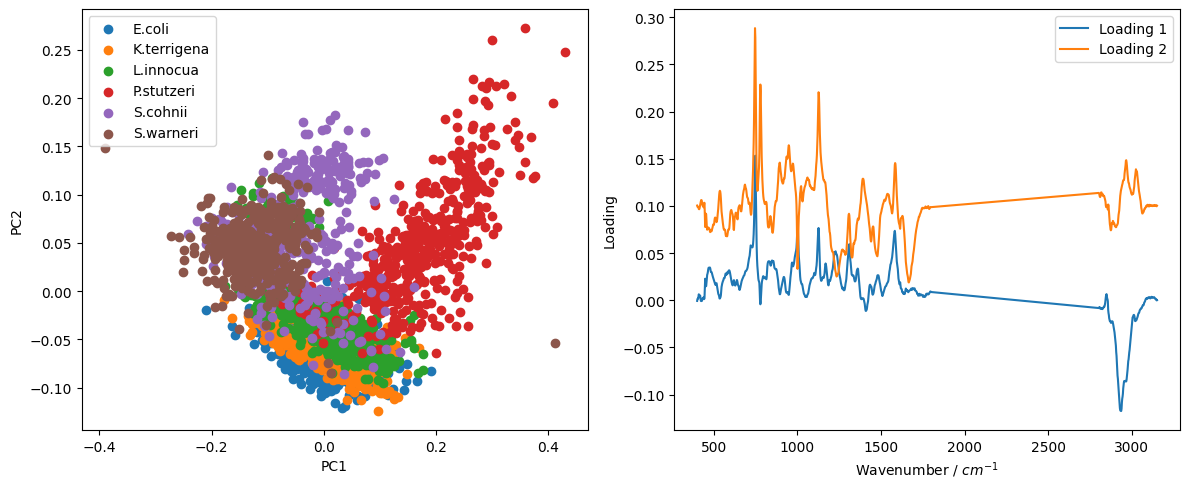

In [12]:
pca_spec = PCA(n_components=10)
pca_spec.fit(spec)
pca_scores = pca_spec.transform(spec)
pca_loadings = pca_spec.components_

uni_labels = np.unique(labels)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, l in enumerate(uni_labels):
    ax[0].scatter(pca_scores[labels==l, 0], pca_scores[labels==l, 1], label=l)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].legend()

ax[1].plot(wn, pca_loadings[0, :], label='Loading 1')
ax[1].plot(wn, pca_loadings[1, :]+0.1, label='Loading 2')
ax[1].set_xlabel('Wavenumber / $cm^{-1}$')
ax[1].set_ylabel('Loading')
ax[1].legend()

plt.tight_layout()
plt.show()

### Partial least squares: supservised dimension reduction

In [13]:
### transfer labels into dummy vectors to perform regression
y_dummy = np.zeros((spec.shape[0], len(uni_labels)))
for i, l in enumerate(uni_labels):
    y_dummy[labels==l, i] = 1

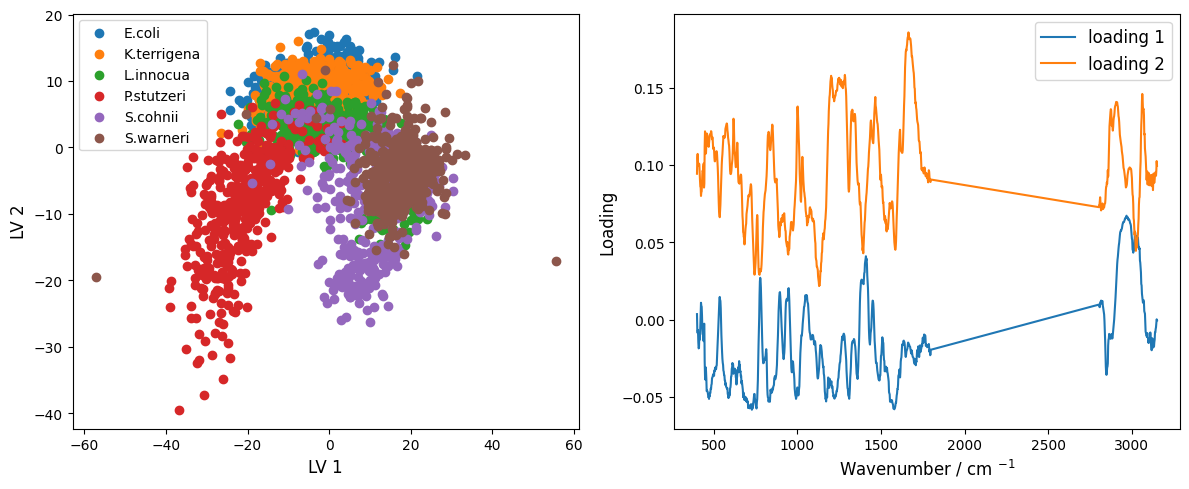

In [14]:
from sklearn.cross_decomposition import PLSRegression
pls = PLSRegression(n_components=10)
pls.fit(spec, y_dummy)

pls_scores = pls.transform(spec)
pls_loadings = pls.x_rotations_

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, l in enumerate(uni_labels):
    ax[0].scatter(pls_scores[labels==l, 0], pls_scores[labels==l, 1], label=l)
ax[0].set_xlabel('LV 1', fontsize=12)
ax[0].set_ylabel('LV 2', fontsize=12)
ax[0].legend()

ax[1].plot(wn, pls_loadings[:, 0], label='loading 1')
ax[1].plot(wn, pls_loadings[:, 1]+0.1, label='loading 2')
ax[1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=12)
ax[1].set_ylabel('Loading', fontsize=12)
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

### Clustering:

In [15]:
## PCA + k-Means
from sklearn.cluster import KMeans

n_cluster = 5  
kmeans_spec = KMeans(n_clusters=n_cluster, random_state=0).fit(spec)
cluster_spec = kmeans_spec.labels_
center_spec = kmeans_spec.cluster_centers_

kmeans_pca = KMeans(n_clusters=n_cluster, random_state=0).fit(pca_scores)
cluster_pca = kmeans_pca.labels_
center_pca = []
for i in np.unique(cluster_pca):
    center_pca.append(np.mean(spec[cluster_pca==i, :], axis=0))
    
center_pca = np.row_stack(center_pca)

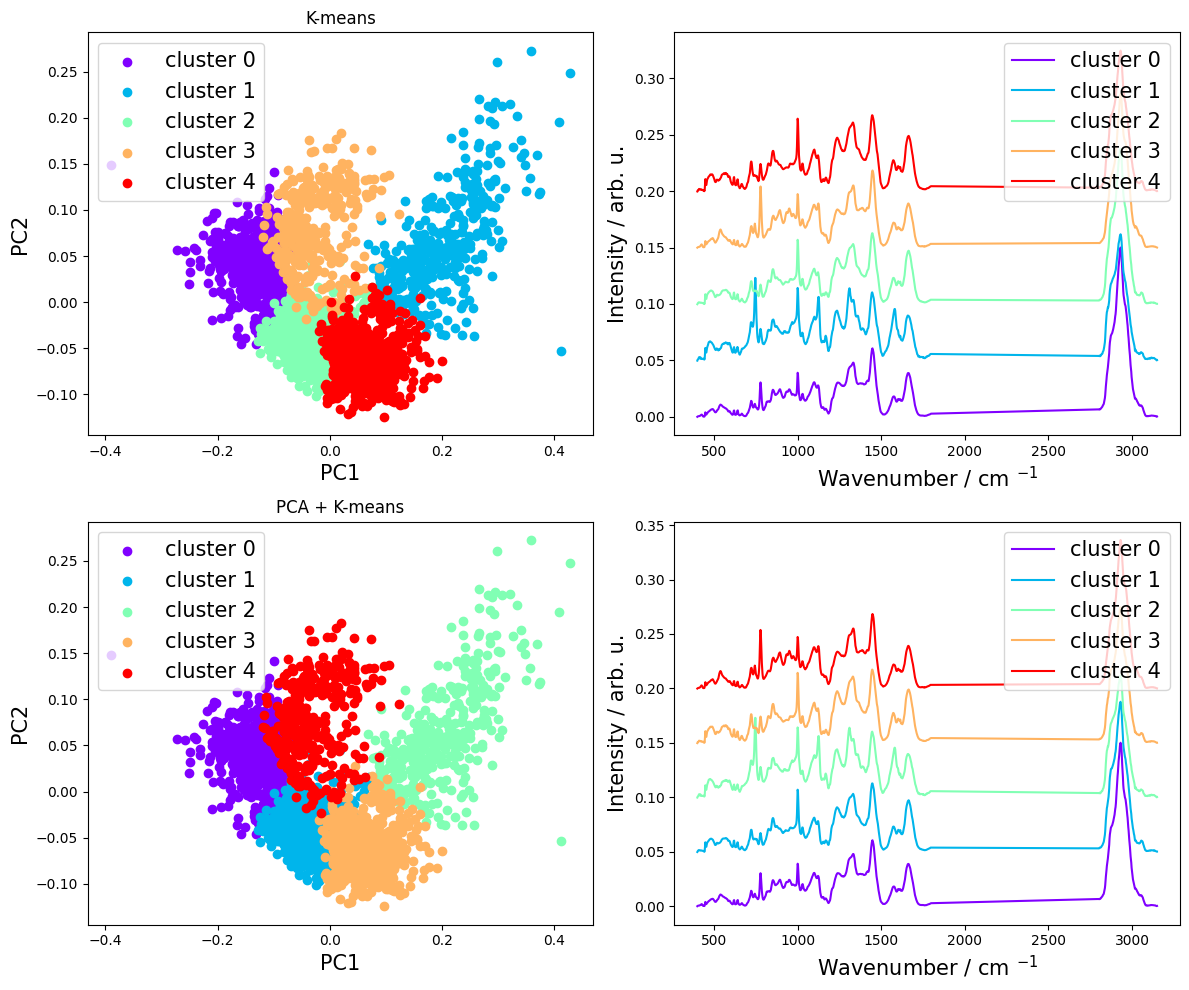

In [16]:
import matplotlib as mpl

colors = mpl.colormaps['rainbow']
colors = colors(np.linspace(0, 1, n_cluster))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i in range(n_cluster):
    ax[0, 0].scatter(pca_scores[cluster_spec==i, 0], pca_scores[cluster_spec==i, 1], color=colors[i], label='cluster '+str(i))
    ax[1, 0].scatter(pca_scores[cluster_pca==i, 0], pca_scores[cluster_pca==i, 1], color=colors[i], label='cluster '+str(i))
ax[0, 0].set_xlabel("PC1", fontsize=15)
ax[0, 0].set_ylabel('PC2', fontsize=15)   
ax[0, 0].legend(fontsize=15)
ax[0, 0].set_title('K-means')

ax[1, 0].set_xlabel("PC1", fontsize=15)
ax[1, 0].set_ylabel('PC2', fontsize=15)   
ax[1, 0].legend(fontsize=15)
ax[1, 0].legend(fontsize=15)
ax[1, 0].set_title('PCA + K-means')

gap = 0.05
for i in range(n_cluster):
    ax[0, 1].plot(wn, center_spec[i, :] + i*gap, color=colors[i], label='cluster '+str(i))
    ax[1, 1].plot(wn, center_pca[i, :] + i*gap, color=colors[i], label='cluster '+str(i))
ax[0, 1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
ax[0, 1].set_ylabel('Intensity / arb. u.', fontsize=15)   
ax[0, 1].legend(fontsize=15)    
ax[1, 1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
ax[1, 1].set_ylabel('Intensity / arb. u.', fontsize=15)   
ax[1, 1].legend(fontsize=15)   

plt.tight_layout()
plt.show()

### hierarchical clustering analysis (HCA)

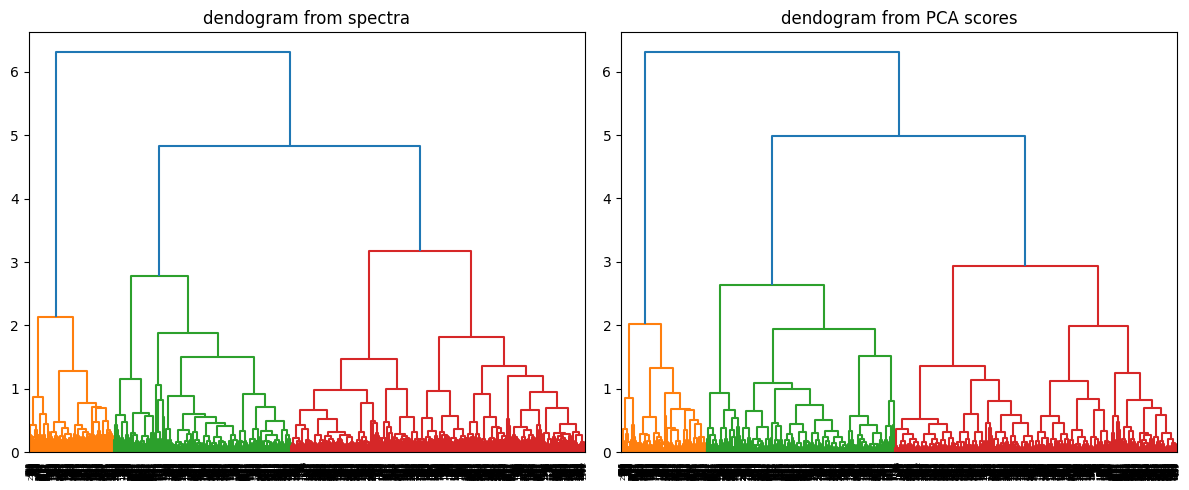

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
linkage_data = linkage(spec, method='ward', metric='euclidean')
dendrogram(linkage_data, ax=ax[0])
ax[0].set_title('dendogram from spectra')
ax[0].set_xticks
linkage_data = linkage(pca_scores, method='ward', metric='euclidean')
dendrogram(linkage_data, ax=ax[1])
ax[1].set_title('dendogram from PCA scores')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.cluster import AgglomerativeClustering

hca_spec = AgglomerativeClustering(n_clusters=n_cluster, affinity='euclidean', linkage='ward')
cluster_hca_spec = hca_spec.fit_predict(spec) 
center_hca_spec = []
for i in np.unique(cluster_hca_spec):
    center_hca_spec.append(np.mean(spec[cluster_hca_spec==i, :], axis=0))
    
center_hca_spec = np.row_stack(center_hca_spec)


hca_pca = AgglomerativeClustering(n_clusters=n_cluster, affinity='euclidean', linkage='ward')
cluster_hca_pca = hca_pca.fit_predict(pca_scores) 
center_hca_pca = []
for i in np.unique(cluster_hca_pca):
    center_hca_pca.append(np.mean(spec[cluster_hca_pca==i, :], axis=0))
    
center_hca_pca = np.row_stack(center_hca_pca)

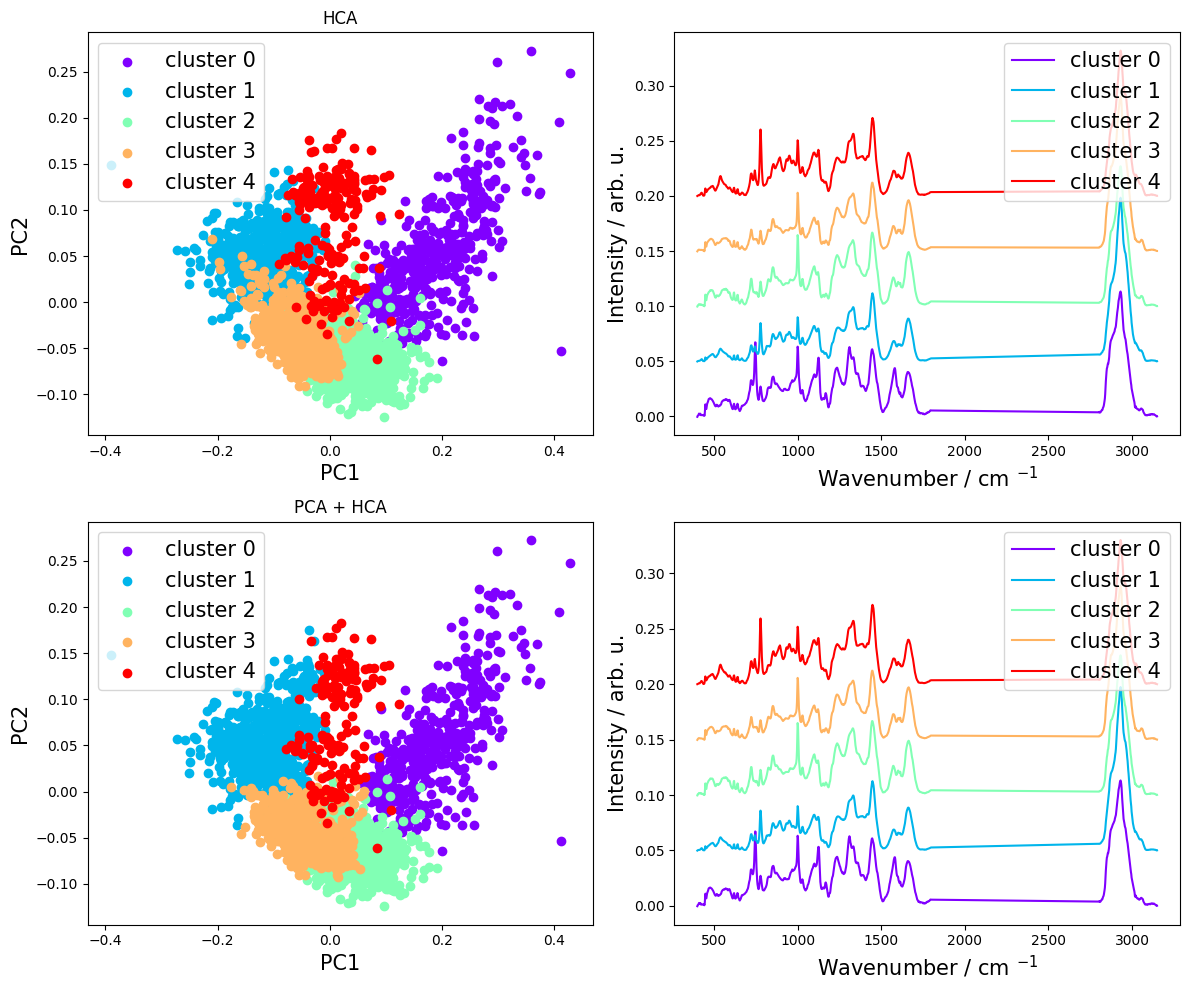

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i in range(n_cluster):
    ax[0, 0].scatter(pca_scores[cluster_hca_spec==i, 0], pca_scores[cluster_hca_spec==i, 1], color=colors[i], label='cluster '+str(i))
    ax[1, 0].scatter(pca_scores[cluster_hca_pca==i, 0], pca_scores[cluster_hca_pca==i, 1], color=colors[i], label='cluster '+str(i))
ax[0, 0].set_xlabel("PC1", fontsize=15)
ax[0, 0].set_ylabel('PC2', fontsize=15)   
ax[0, 0].legend(fontsize=15)
ax[0, 0].set_title('HCA')

ax[1, 0].set_xlabel("PC1", fontsize=15)
ax[1, 0].set_ylabel('PC2', fontsize=15)   
ax[1, 0].legend(fontsize=15)
ax[1, 0].legend(fontsize=15)
ax[1, 0].set_title('PCA + HCA')

gap = 0.05
for i in range(n_cluster):
    ax[0, 1].plot(wn, center_hca_spec[i, :] + i*gap, color=colors[i], label='cluster '+str(i))
    ax[1, 1].plot(wn, center_hca_pca[i, :] + i*gap, color=colors[i], label='cluster '+str(i))
ax[0, 1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
ax[0, 1].set_ylabel('Intensity / arb. u.', fontsize=15)   
ax[0, 1].legend(fontsize=15)    
ax[1, 1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
ax[1, 1].set_ylabel('Intensity / arb. u.', fontsize=15)   
ax[1, 1].legend(fontsize=15)   

plt.tight_layout()
plt.show()

### classification

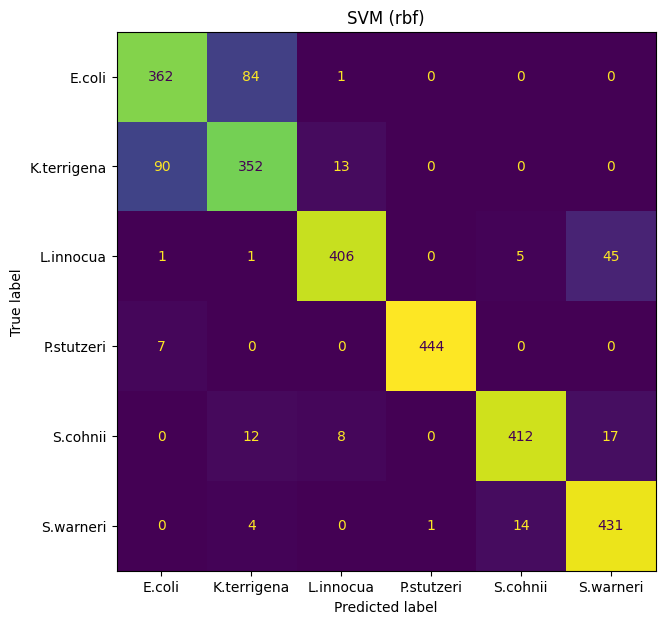

In [20]:
### nonlinear classification
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf_svm = svm.SVC(C=1.0, kernel='rbf')
clf_svm.fit(spec, labels)
pred = clf_svm.predict(spec)

cmat_svm = confusion_matrix(labels, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_svm, display_labels=np.unique(labels))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('SVM (rbf)')
plt.show()

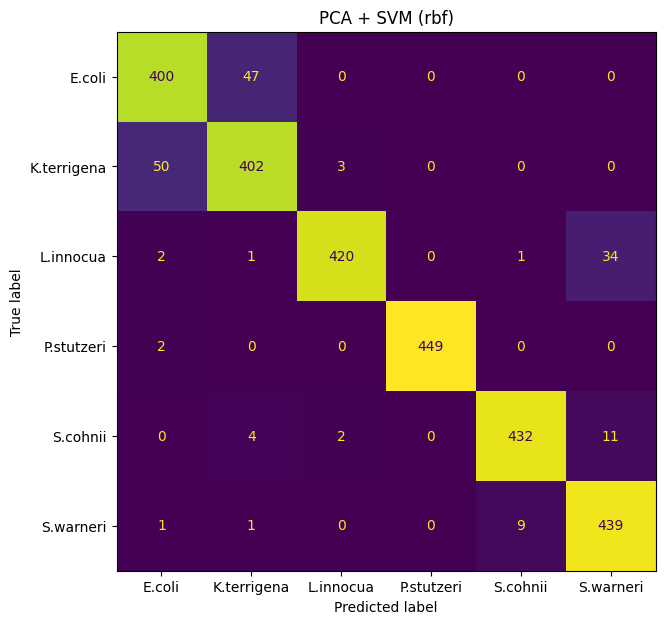

In [21]:
### nonlinear classification
clf_svm = svm.SVC(C=1.0, kernel='rbf')
clf_svm.fit(pca_scores, labels)
pred = clf_svm.predict(pca_scores)
cmat_svm = confusion_matrix(labels, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_svm, display_labels=np.unique(labels))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('PCA + SVM (rbf)')
plt.show()

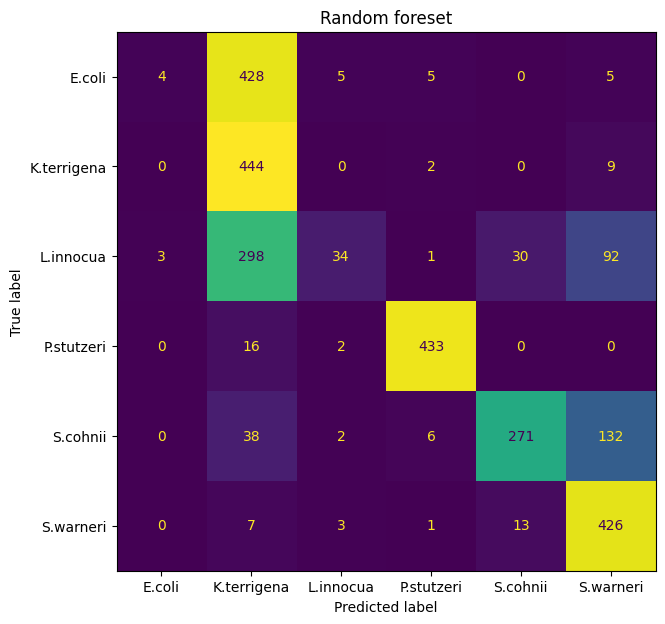

In [22]:
### random forest
from sklearn.ensemble import RandomForestClassifier
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0)
clf_rf.fit(spec, labels)

pred = clf_rf.predict(spec)
cmat_svm = confusion_matrix(labels, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_svm, display_labels=np.unique(labels))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('Random foreset')
plt.show()

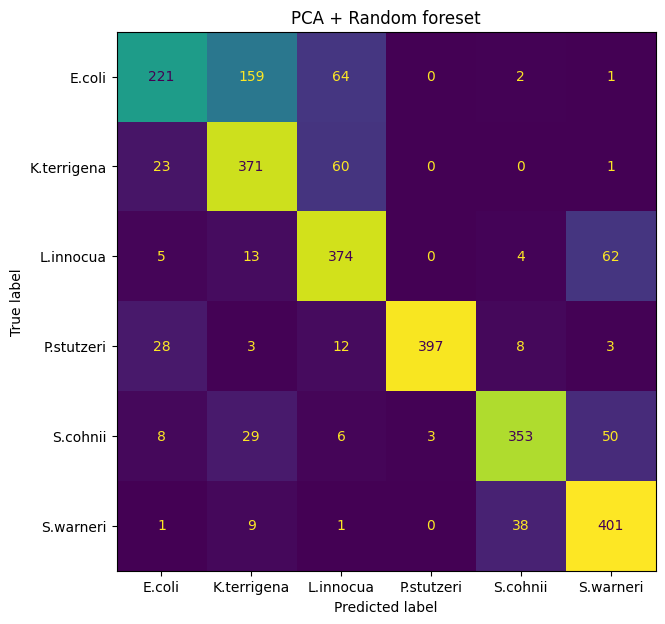

In [ ]:
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0)
clf_rf.fit(pca_scores, labels)

pred = clf_rf.predict(pca_scores)
cmat_svm = confusion_matrix(labels, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_svm, display_labels=np.unique(labels))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('PCA + Random foreset')
plt.show()

### Pipeline with cross-validation

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score

class Classify(object):
    def __init__(self, spec, labels, batches):
        self.spec = spec
        self.labels = labels
        self.batches = batches
    
    def model(self, ix_train, ix_test, nPC=15, method=['LDA', 'SVM', 'RF'], cost=2, ntrees=100, max_depth=2):
        m_PCA = PCA(n_components = nPC).fit(self.spec[ix_train, :])
        
        scr_train = m_PCA.transform(self.spec[ix_train, :])
        scr_test = m_PCA.transform(self.spec[ix_test, :])

        if 'SVM' in method:
            model = svm.SVC(C=cost, class_weight='balanced')
        elif 'RF' in method:
            model = RandomForestClassifier(n_estimators=ntrees, max_depth=2, random_state=0)
        else:
            model = LinearDiscriminantAnalysis()

        model.fit(scr_train, self.labels[ix_train])
        pred = model.predict(scr_test)
   
        return pred
        
    def do_CV(self, nPC=15, method=['LDA', 'SVM', 'RF'], cost=2, ntrees=100, max_depth=2):
        log = LeaveOneGroupOut()     ### leave one replicate our cross-validation
        pred = np.zeros_like(self.labels)
        accs = []
        for i, (train_index, test_index) in enumerate(log.split(self.spec, self.labels, self.batches)):
            pred[test_index] = self.model(train_index, test_index, nPC=nPC, method=method, cost=cost)
            accs = np.append(accs, balanced_accuracy_score(self.labels[test_index], pred[test_index]))    
        return accs, pred

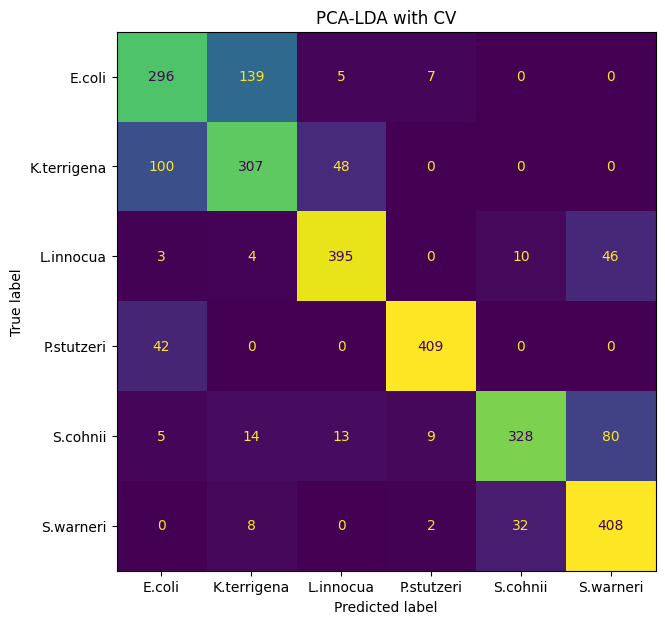

In [ ]:
cls_model = Classify(spec, labels, batches)
acc, pred = cls_model.do_CV(nPC=10, method='LDA')

cmat_svm = confusion_matrix(labels, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_svm, display_labels=np.unique(labels))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('PCA-LDA with CV')
plt.show()